# Experiment 1: learn representations

## Preliminary

In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# introduce the DKRL algorithm
import numpy as np
from tqdm import tqdm

def DKRL(y, KZ, KX, N, r, penalty, tol, T, wt = 0, verbose = 0):
    """
    Perform an double kernel representation learning.

    Parameters:
    y (numpy.ndarray): Target vector for optimization.
    KZ (numpy.ndarray): Kernel matrix Z.
    KX (numpy.ndarray): Kernel matrix X.
    N (int): Number of rows in U and V matrices.
    r (int): Number of columns in U and V matrices.
    penalty (float): Regularization parameter.
    tol (float): Tolerance for stopping criterion.
    T (int): Maximum number of iterations.
    wt (float): a number between 0 and 1 for adding identity to degenerate kernel matrix
    

    Returns:
    tuple: Final U and V matrices.
    """
    # Initialize U and V matrices randomly
    Ut = np.random.normal(loc=0, scale=1, size=(N, r))
    Vt = np.random.normal(loc=0, scale=1, size=(N, r))

    for iter in tqdm(range(T)):
        # Update U matrix
        VKX = np.repeat(np.dot(Vt.T, KX), repeats=N, axis=0)
        KZZ = np.tile(KZ, (1, r))
        DesignVt = VKX.T * KZZ  # n * (nr)
        Utt = np.linalg.solve(
            np.dot(DesignVt.T, DesignVt) + penalty * np.kron(np.eye(r, dtype=int), (1-wt) * KZ + wt * np.eye(N)),
            np.dot(DesignVt.T, y)
        )
        Utt = Utt.reshape((N, r), order="F")

        # Update V matrix
        UKZ = np.repeat(np.dot(Utt.T, KZ), repeats=N, axis=0)
        KXX = np.tile(KX, (1, r))
        DesignUt = UKZ.T * KXX  # n * (nr)
        Vtt = np.linalg.solve(
            np.dot(DesignUt.T, DesignUt) + penalty * np.kron(np.eye(r, dtype=int), (1-wt) * KX + wt * np.eye(N)),
            np.dot(DesignUt.T, y)
        )
        Vtt = Vtt.reshape((N, r), order="F")

        # Check stopping criterion
        norm_U = np.linalg.norm(Utt - Ut) / (np.linalg.norm(Ut) + 1e-3)
        norm_V = np.linalg.norm(Vtt - Vt) / (np.linalg.norm(Vt) + 1e-3)
        if verbose:
            print(f"Iteration {iter}: norm_U={norm_U}, norm_V={norm_V}")
        
        
        if norm_U < tol and norm_V < tol:
            break

        # Update Ut and Vt
        Ut = Utt
        Vt = Vtt

    y_pred = np.diag(KZ @ Utt @ Vtt.T @ KX)
    return Utt, Vtt, y_pred



In [ ]:
def DKRL_pred(U, V, KZ_pred, KX_pred):
    y_pred = np.diag(KZ_pred.T @ U @ V.T @ KX_pred)
    return y_pred
    

## Sensitivity of hyperparameters

In [ ]:
# import the headlines and embeddings
num_actions = 50
df = pd.read_csv("unique_headlines.csv")  # Replace with your file path
headlines = np.array(df["headline"].tolist())
embeddings = np.loadtxt('embeddings.csv', delimiter=',')

# Randomly sample a subset of headlines and embeddings for evaluation
# Set a random seed for reproducibility
np.random.seed(2025)
ind = np.arange(len(headlines))  # Array with 1000 elements
sampled_ind = np.random.choice(ind, size=num_actions, replace=False)

# Randomly sample 100 elements from the array
headlines = headlines[sampled_ind]
Z = embeddings[sampled_ind]

# dimension of the embeddings
p = len(Z[1])
print("the dimension of the embeddings is: " + str(len(Z[1])))

# ============================================================================ #

# Simulate projection matrix
# Simulate covariate level features from Gaussian distributions
np.random.seed(2025)
r = 3
# p = 1000
# Z = np.random.normal(loc=0, scale=1, size=(N, p))
# row_norms_Z = np.linalg.norm(Z, axis=1, keepdims=True)
# Z = Z / row_norms_Z
# sampled_ind = np.random.choice(range(N), size=N, replace=True)
# Z = Z[sampled_ind]

q = 1000
X = np.random.normal(loc=0, scale=1, size=(num_actions, q))
row_norms_X = np.linalg.norm(X, axis=1, keepdims=True)
X = X / row_norms_X

# generate random projection
np.random.seed(2025)
P = np.random.normal(loc=0, scale=1, size=(p, q))
L, S, Rt = np.linalg.svd(P, full_matrices=False)
Lr = L[:, :r]
Rr = Rt[:r, :].T
Zr = np.dot(Z, Lr) # n*r
Xr = np.dot(X, Rr) # n*r

# True reward matrix
true_reward = Zr @ Xr.T
best_reward = np.max(true_reward, axis=0)

# ============================================================================ #

# Set the random seed for reproducibility
np.random.seed(2025)







In [13]:
np.random.seed(2025)
tol = 1e-2
T = 200
# Define the number of simulations
num_simulations = 20
N = 500
# num_actions = 50  # Assuming actions correspond to columns

# Store cumulative regrets
# all_cum_regrets = np.zeros((num_simulations, num_exploration + num_exploitation))

# Define parameter values for iteration
rank_run_values = [1, 3, 5]
penalty_values = [1e-4, 1e-3, 1e-2, 1e-1, 1e0]

# Dictionary to store test errors for each (rank_run, penalty) combination.
test_errors = {}

# Iterate over all combinations of rank_run and penalty
for rank_run in rank_run_values:
    for penalty in penalty_values:
        errors = []  # list to store test_err for each simulation run
        for sim in tqdm(range(num_simulations), desc=f"rank_run={rank_run}, penalty={penalty}"):
            # ========= Exploration Stage ==========
            sampled_ind_z = np.random.choice(range(num_actions), size=N, replace=True)
            Zsub = Z[sampled_ind_z]
            sampled_ind_x = np.random.choice(range(num_actions), size=N, replace=True)
            Xsub = X[sampled_ind_x]

            Zrsub = np.dot(Zsub, Lr)  # n*r
            Xrsub = np.dot(Xsub, Rr)  # n*r
            y = np.diag(Zrsub @ Xrsub.T)

            KZsub = np.dot(Zsub, Zsub.T)
            KXsub = np.dot(Xsub, Xsub.T)
            KZXsub = KZsub * KXsub

            N_train, N_test = int(0.9 * N), int(0.1 * N)
            train_id = np.random.choice(range(N), size=N_train, replace=False)
            test_id = np.array(list(set(range(N)) - set(train_id)))

            # Training data
            KZ_train = KZsub[np.ix_(train_id, train_id)]
            KX_train = KXsub[np.ix_(train_id, train_id)]
            KZX_train = KZXsub[np.ix_(train_id, train_id)]
            y_train = y[train_id]

            # Testing data
            KZ_test = KZsub[np.ix_(train_id, test_id)]
            KX_test = KXsub[np.ix_(train_id, test_id)]
            KZX_test = KZXsub[np.ix_(train_id, test_id)]
            y_test = y[test_id]

            # Generate the outcome using DKRL
            U, V, y_hat = DKRL(y_train, KZ_train, KX_train, N_train, rank_run, penalty, tol, T, wt=0.01)
            y_pred = DKRL_pred(U, V, KZ_test, KX_test)
            test_err = np.sqrt(np.linalg.norm(y_test - y_pred) ** 2 / N_test)
            
            errors.append(test_err)
        
        # Store the list of errors for this parameter combination
        test_errors[(rank_run, penalty)] = errors


np.save("test_errors.npy", test_errors)
print("Test errors saved to test_errors.npy")        

rank_run=5, penalty=1.0: 100%|██████████| 20/20 [00:48<00:00,  2.44s/it]

Test errors saved to test_errors.npy


In [14]:
test_errors

{(1, 0.0001): [0.005894293143107594,
  0.00669860745163146,
  0.016342942382873437,
  0.017181759102352222,
  0.005578596449194722,
  0.0053396993646736505,
  0.009346369393861818,
  0.07506184399207594,
  0.006276226841271551,
  0.017192392424308683,
  0.02454354473459891,
  0.00983244124732558,
  0.005918663024860253,
  0.007328306187596777,
  0.0043428004540376165,
  0.049168045972496466,
  0.034484727431188605,
  0.008922664320996358,
  0.03360792700579653,
  0.006532118611384882],
 (1, 0.001): [0.005163401811138873,
  0.0063142015975852835,
  0.005894844004016087,
  0.007251578344009422,
  0.006757315175226486,
  0.009402343607350021,
  0.021657882440113106,
  0.007813537015766137,
  0.004622558176860519,
  0.006669882429187805,
  0.004836539784790644,
  0.00486381563384848,
  0.005839071051422672,
  0.006196963806370414,
  0.005871128217809053,
  0.005317630090256737,
  0.014428690513854215,
  0.004852050725644959,
  0.007789230850102285,
  0.006377818023368939],
 (1, 0.01): [0.0

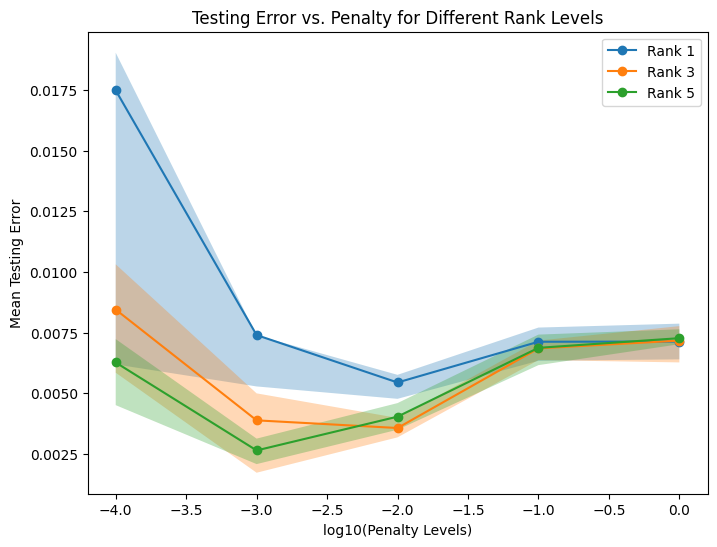

Plot saved as test_error_plot.png


<Figure size 640x480 with 0 Axes>

In [19]:
log_penalties = np.log10(penalty_values)

plt.figure(figsize=(8, 6))
for rank in rank_run_values:
    means = []
    lower = []  # lower quantile (25th percentile)
    upper = []  # upper quantile (75th percentile)
    for penalty in penalty_values:
        errors = np.array(test_errors[(rank, penalty)])
        means.append(np.mean(errors))
        lower.append(np.quantile(errors, 0.25))
        upper.append(np.quantile(errors, 0.75))
    means = np.array(means)
    lower = np.array(lower)
    upper = np.array(upper)
    
    plt.plot(log_penalties, means, marker='o', label=f"Rank {rank}")
    plt.fill_between(log_penalties, lower, upper, alpha=0.3)

plt.xlabel("log10(Penalty Levels)")
plt.ylabel("Mean Testing Error")
plt.title("Testing Error vs. Penalty for Different Rank Levels")
plt.legend()
plt.show()

plt.savefig("test_error_plot.png")
print("Plot saved as test_error_plot.png")